# Анализ сезонности спроса

<font color="blue">Яндекс Wordstat</font>

Для анализа Яндекс Wordstat сначала выгрузим данные вручную в формате csv. Рассматриваемый период: максимально возможный в вордстате. С января 2018 по май 2026

In [64]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [78]:
import pandas as pd
import matplotlib.pyplot as plt

In [103]:
df_dynamics = pd.read_csv('/content/drive/MyDrive/wordstat_dynamic (2).csv', sep=';')
df_dynamics.drop(columns='Динамика частотности запросов «Сорбет», по неделям, 01.01.2018 — 10.05.2026, все регионы, все устройства', inplace=True)
df_dynamics

,Неделя с,Число запросов,"Доля от всех запросов, %"
0,01.01.2018,2 833,"0,00019"
1,08.01.2018,3 158,"0,00018"
2,15.01.2018,3 583,"0,00019"
3,22.01.2018,3 750,"0,00019"
4,29.01.2018,3 666,"0,00019"
...,...,...,...
431,06.04.2026,8 980,"0,00033"
432,13.04.2026,9 441,"0,00035"
433,20.04.2026,9 703,"0,00036"
434,27.04.2026,10 158,"0,00040"


In [104]:
df_dynamics['Неделя с'] = pd.to_datetime(df_dynamics['Неделя с'], format='%d.%m.%Y')
df_dynamics['Год'] = df_dynamics['Неделя с'].dt.year
df_dynamics['Месяц'] = df_dynamics['Неделя с'].dt.month

In [105]:
df_dynamics['Число запросов'] = df_dynamics['Число запросов'].str.replace(" ", "", regex=False)
df_dynamics['Число запросов'] = pd.to_numeric(df_dynamics['Число запросов'])

In [106]:
df_dynamics['Скользящее среднее'] = df_dynamics['Число запросов'].rolling(window=3, min_periods=1).mean()

Выделим сезонные коеффициенты по месяцам как отношение максимума по этому месяцу к среднему по этому месяцу.

In [107]:
monthly_data = df_dynamics.groupby(['Год', 'Месяц'])['Число запросов'].mean().reset_index()
monthly_data.rename(columns={"Число запросов": "Среднее число запросов в месяц"}, inplace=True)
yearly_avg = monthly_data.groupby('Год')['Среднее число запросов в месяц'].mean().reset_index()
yearly_avg.rename(columns={"Среднее число запросов в месяц": "Среднее число запросов в год"}, inplace=True)

In [108]:
monthly_data = monthly_data.merge(yearly_avg, on='Год')

In [109]:
monthly_data['Коэффициент сезонности'] = monthly_data['Среднее число запросов в месяц'] / monthly_data['Среднее число запросов в год']
monthly_data = monthly_data.sort_values(['Год', 'Месяц'])
monthly_data

,Год,Месяц,Среднее число запросов в месяц,Среднее число запросов в год,Коэффициент сезонности
0,2018,1,3398.00,4498.804167,0.755312
1,2018,2,3691.75,4498.804167,0.820607
2,2018,3,4307.25,4498.804167,0.957421
3,2018,4,3799.60,4498.804167,0.844580
4,2018,5,5143.50,4498.804167,1.143304
...,...,...,...,...,...
96,2026,1,8607.00,9401.810000,0.915462
97,2026,2,8552.75,9401.810000,0.909692
98,2026,3,9218.80,9401.810000,0.980535
99,2026,4,9570.50,9401.810000,1.017942


In [113]:
monthly_data['Год'] = monthly_data['Год'].astype(str)
monthly_data['Месяц'] = monthly_data['Месяц'].astype(str)
monthly_data['Год_месяц'] = monthly_data['Год'] + '.' + monthly_data['Месяц']
monthly_data

,Год,Месяц,Среднее число запросов в месяц,Среднее число запросов в год,Коэффициент сезонности,Год_месяц
0,2018,1,3398.00,4498.804167,0.755312,2018.1
1,2018,2,3691.75,4498.804167,0.820607,2018.2
2,2018,3,4307.25,4498.804167,0.957421,2018.3
3,2018,4,3799.60,4498.804167,0.844580,2018.4
4,2018,5,5143.50,4498.804167,1.143304,2018.5
...,...,...,...,...,...,...
96,2026,1,8607.00,9401.810000,0.915462,2026.1
97,2026,2,8552.75,9401.810000,0.909692,2026.2
98,2026,3,9218.80,9401.810000,0.980535,2026.3
99,2026,4,9570.50,9401.810000,1.017942,2026.4


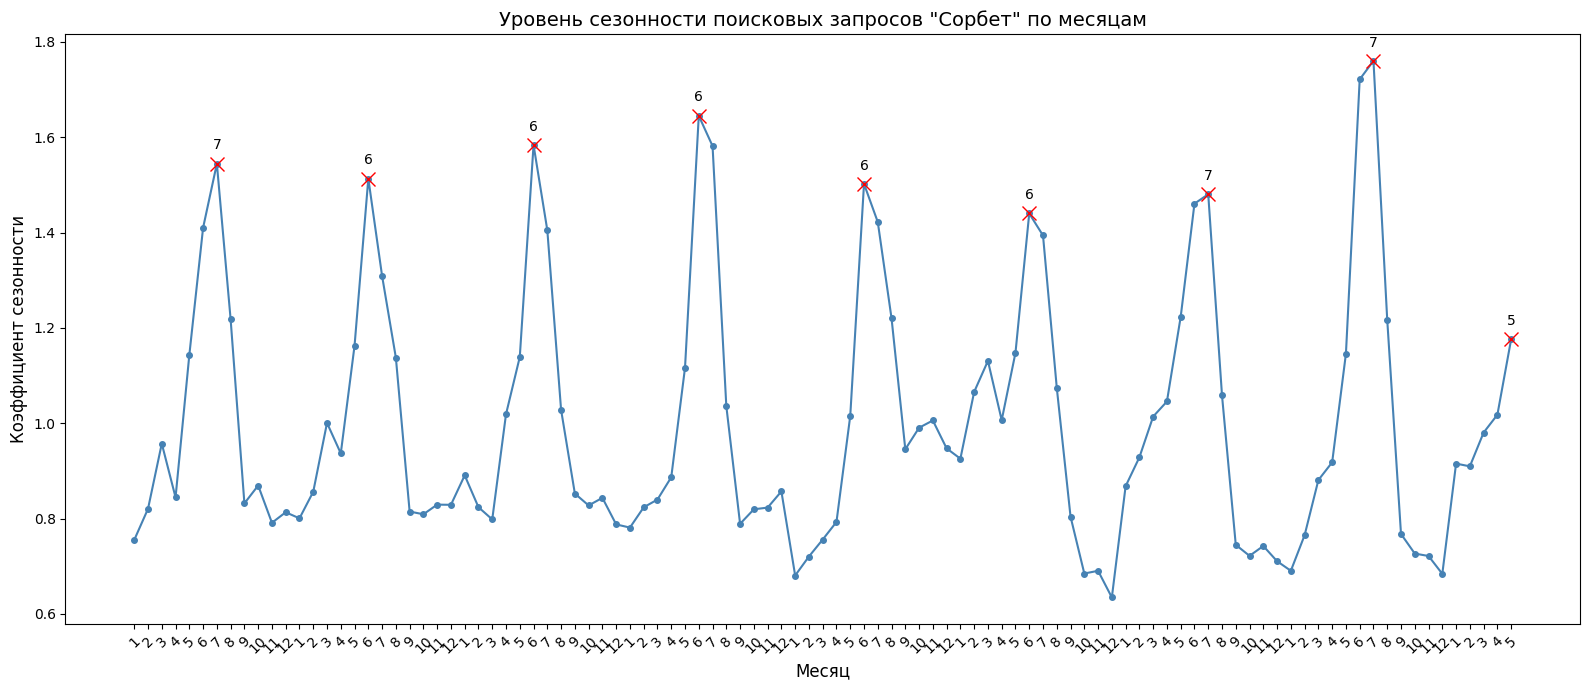

In [114]:
plt.figure(figsize=(16, 7))
plt.plot(monthly_data['Год_месяц'], monthly_data['Коэффициент сезонности'],
         marker='o', linestyle='-', linewidth=1.5, markersize=4,
         color='steelblue', label='Коэффициент сезонности')
month_labels = monthly_data['Месяц'].tolist()  # числа от 1 до 12
plt.xticks(ticks=range(len(monthly_data)), labels=month_labels, rotation=45)
plt.title('Уровень сезонности поисковых запросов "Сорбет" по месяцам', fontsize=14)
plt.xlabel('Месяц', fontsize=12)
plt.ylabel('Коэффициент сезонности', fontsize=12)

for year in monthly_data['Год'].unique():
  year_data = monthly_data[monthly_data['Год'] == year]
  peak = year_data.loc[year_data['Коэффициент сезонности'].idxmax()]

  plt.plot(peak['Год_месяц'], peak['Коэффициент сезонности'],
           'rx', markersize=10)
  plt.text(peak['Год_месяц'], peak['Коэффициент сезонности'] + 0.03,
           f'{peak['Месяц']}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

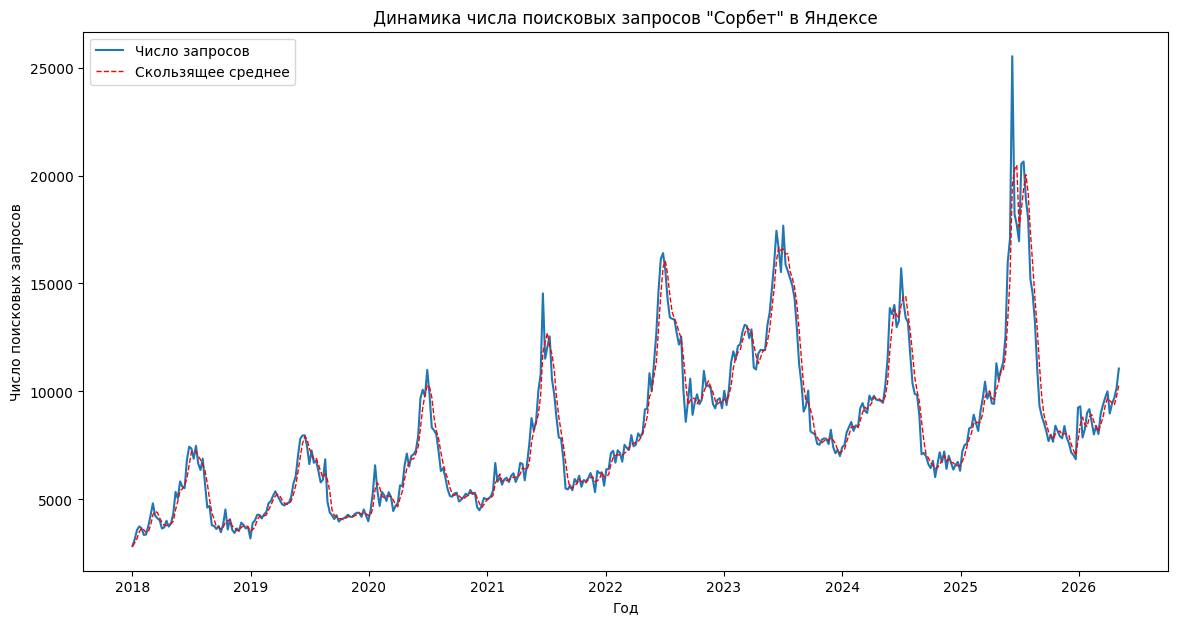

In [118]:
plt.figure(figsize=(14, 7))
plt.plot(df_dynamics['Неделя с'], df_dynamics['Число запросов'], label='Число запросов')

plt.plot(df_dynamics['Неделя с'], df_dynamics['Скользящее среднее'],
         linewidth=1, linestyle='--', color='red', label = 'Скользящее среднее')

plt.legend()
plt.title('Динамика числа поисковых запросов "Сорбет" в Яндексе', fontsize=12)
plt.xlabel('Год', fontsize=10)
plt.ylabel('Число поисковых запросов', fontsize=10)
plt.show()


**Выводы про динамику**
1. Число запросов от пользователей растет каждый год -> отрасль растет -> можно рассчитывать на рост спроса в долгосрочной перспективе.
2. Наблюдается явная сезонность спроса. Пик активности приходится на июнь/июль. Это связано с особо теплой погодой в это время.